In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('nigeria.csv', comment='#')


In [3]:
data['Country'] = 'Kenya'

In [4]:
data['Date']=pd.to_datetime(data['YEAR'] * 1000 + data['DOY'], format = '%Y%j')

In [5]:
data['Month']=data['Date'].dt.month

In [6]:
data = data.replace(-999, np.nan)

In [16]:
duplicates = data.duplicated().sum()
print(f"Total number of duplicates {duplicates}")

Total number of duplicates 0


### Duplicates

There are **0** duplicates in the whole dataset.

In [8]:
data.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,26.656928,28.914667,24.886461,4.028206,4.213914,85.237040,2.217135,2.903335,100.827205,18.558505,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,21.120000,25.260000,15.170000,1.160000,0.000000,54.400000,0.740000,1.290000,100.380000,9.430000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.720000,27.920000,24.100000,3.090000,0.330000,83.930000,1.770000,2.370000,100.710000,17.970000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,26.820000,28.990000,25.100000,3.770000,1.840000,86.350000,2.200000,2.810000,100.820000,18.840000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,27.540000,29.910000,25.860000,4.600000,5.200000,88.500000,2.630000,3.390000,100.950000,19.570000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,29.290000,32.880000,27.790000,11.730000,166.100000,93.790000,4.780000,6.000000,101.350000,21.740000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.123335,1.294345,1.396727,1.399169,7.266742,5.446007,0.587191,0.696885,0.165321,1.646313,NaN,3.477046


### Statistics Interpretation

Temperature (T2M) averages around 20.4°C, confirming a generally mild and stable climate with a narrow range of variation. The diurnal cycle remains consistent, with moderate differences between daily highs and lows.

However, when looking at the relationship between temperature and humidity, a clearer pattern emerges. The scatter plot shows that higher humidity values tend to cluster around slightly lower to moderate temperatures, rather than the highest temperatures. This suggests that peak heat is not necessarily associated with peak moisture.

Precipitation (PRECTOTCORR), represented by bubble size, is highly uneven and concentrated in specific regions of the plot. Larger rainfall events tend to occur where humidity is high, reinforcing the expected link between atmospheric moisture and rainfall. These events are not spread uniformly across temperatures, indicating that rainfall is more sensitive to humidity than to temperature alone.

Humidity (RH2M ~66%) and specific humidity (QV2M ~11 g/kg) still indicate a moderately moist atmosphere, but the visualization highlights that high humidity is a key driver of rainfall variability. Periods of lower humidity show almost no rainfall activity.

Wind speeds remain light to moderate, and surface pressure continues to show minimal variation, suggesting that large-scale atmospheric stability is maintained despite variability in rainfall.

Overall, the dataset reflects a stable climate in terms of temperature and pressure, but with rainfall patterns strongly tied to humidity levels rather than temperature extremes. This points to moisture availability being the dominant factor in precipitation events, rather than heat-driven convection alone.


In [9]:
data.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month          0
dtype: int64

### Null Values

There are 0 null values.


In [10]:
columns = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

In [11]:
z_scores = (data[columns] - data[columns].mean()) / data[columns].std()

In [12]:
outliers = (np.abs(z_scores) > 3).any(axis=1)

outlier_count = outliers.sum()
print(f"Total number of outlier rows: {outlier_count}")

Total number of outlier rows: 225


In [13]:
data[columns] = data[columns].clip(
    lower=data[columns].quantile(0.01),
    upper=data[columns].quantile(0.99),
    axis=1
)

### Outlier Detection and Basic Cleaning

Since this is a weather dataset, natural spikes are expected. That's why I have decided to cap the outliers 

instead of deleting them. They were identified using a z-score of greater than 3. They are capped using 1st anf 

99th percentile. This preserved important extreme weather events while reducing the influence of noisy values.

In [14]:
data.to_csv('data/kenya_clean.csv', index = False)

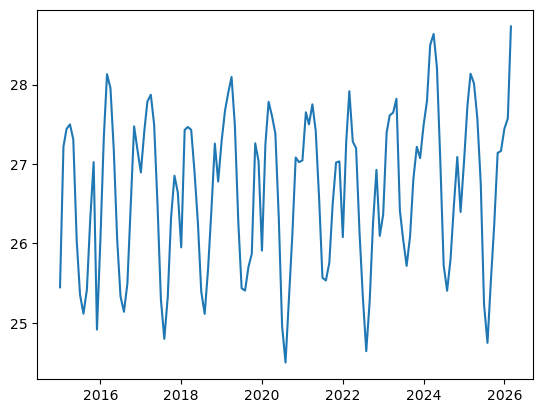

In [15]:
monthly_temp = data.groupby(['YEAR', 'Month'])['T2M'].mean().reset_index()
monthly_temp["Date"] = pd.to_datetime(
    monthly_temp["YEAR"].astype(str) + "-" + monthly_temp["Month"].astype(str)
)

plt.figure()
plt.plot(monthly_temp["Date"], monthly_temp["T2M"])

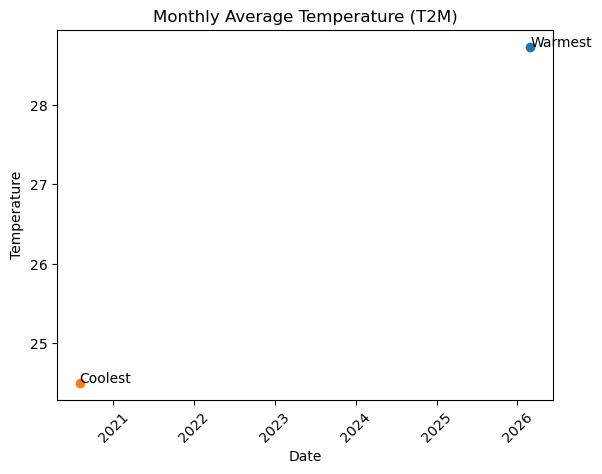

In [17]:
max_row = monthly_temp.loc[monthly_temp["T2M"].idxmax()]
min_row = monthly_temp.loc[monthly_temp["T2M"].idxmin()]

plt.scatter(max_row["Date"], max_row["T2M"])
plt.scatter(min_row["Date"], min_row["T2M"])

plt.text(max_row["Date"], max_row["T2M"], "Warmest")
plt.text(min_row["Date"], min_row["T2M"], "Coolest")

plt.title("Monthly Average Temperature (T2M)")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.xticks(rotation=45)
plt.show()

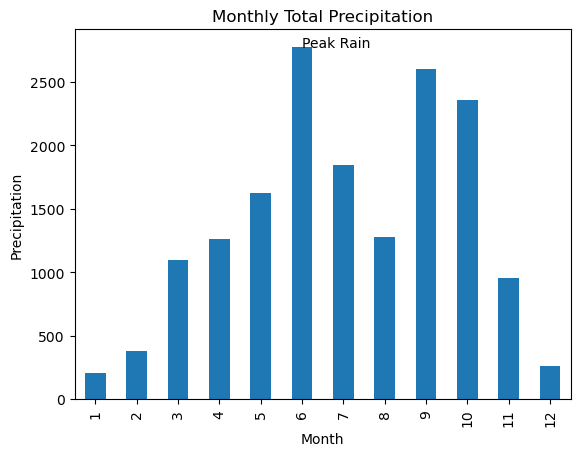

In [18]:
monthly_rain = data.groupby('Month')['PRECTOTCORR'].sum()

plt.figure()
monthly_rain.plot(kind="bar")

# Highlight peak
peak_month = monthly_rain.idxmax()
peak_value = monthly_rain.max()

plt.text(peak_month-1, peak_value, "Peak Rain")

plt.title("Monthly Total Precipitation")
plt.xlabel("Month")
plt.ylabel("Precipitation")
plt.show()

### Analysis

Temperature varies seasonally with clear warm and cool periods. The peak rainfall is recorded on June. As for 

the temperature, the coolest is recording in the year 2021 and the warmest on 2026.

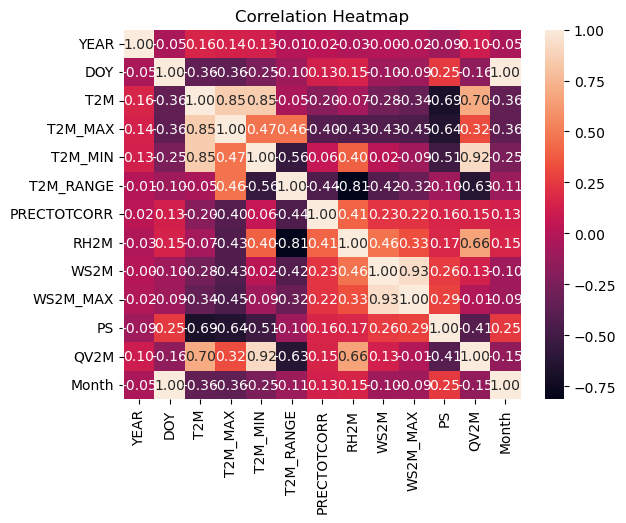

In [19]:
plt.figure()
corr = data.corr(numeric_only=True)

sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

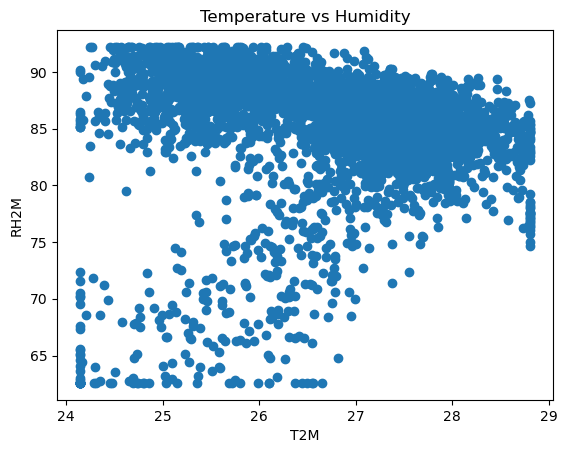

In [20]:
plt.figure()
plt.scatter(data["T2M"], data["RH2M"])
plt.xlabel("T2M")
plt.ylabel("RH2M")
plt.title("Temperature vs Humidity")
plt.show()

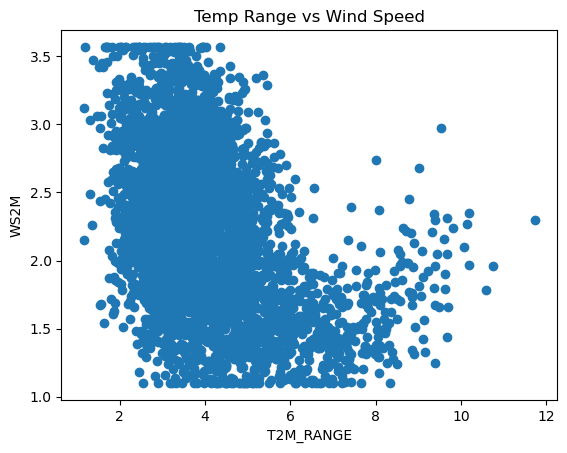

In [21]:
plt.figure()
plt.scatter(data["T2M_RANGE"], data["WS2M"])
plt.xlabel("T2M_RANGE")
plt.ylabel("WS2M")
plt.title("Temp Range vs Wind Speed")
plt.show()

In [22]:
corr_pairs = corr.unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1]  

print(corr_pairs.head(7))

DOY       Month       0.996557
Month     DOY         0.996557
WS2M      WS2M_MAX    0.930013
WS2M_MAX  WS2M        0.930013
T2M_MIN   QV2M        0.919288
QV2M      T2M_MIN     0.919288
T2M_MAX   T2M         0.849193
dtype: float64


### Correlation Interpretation

The strongest correlations in the dataset highlight both redundancy in features and meaningful physical relationships.

DOY and Month show an almost perfect correlation (~0.997), confirming that they represent the same temporal progression and are effectively interchangeable.

Wind-related variables exhibit a very strong relationship, with WS2M and WS2M_MAX (~0.93) closely aligned. This indicates that average and maximum wind speeds tend to move together consistently, suggesting stable wind patterns with limited abrupt spikes.

A particularly strong relationship appears between T2M_MIN and QV2M (~0.92). This suggests that higher minimum temperatures are closely associated with higher moisture content in the air. In practical terms, warmer nights tend to retain more atmospheric moisture, which is a meaningful physical relationship rather than redundancy.
Temperature variables also remain strongly connected, with T2M and T2M_MAX (~0.85) showing a high correlation. This reflects consistent daily temperature behavior, where increases in average temperature are accompanied by higher daytime peaks.

Overall, the dataset shows some expected redundancy in time variables, while also capturing strong environmental relationships. Notably, moisture is more tightly linked to minimum temperature than to relative humidity in this case, pointing to the role of nighttime conditions in moisture retention.

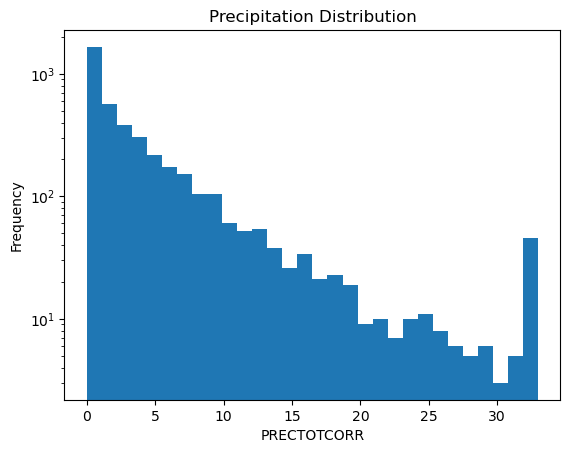

In [23]:
plt.figure()
plt.hist(data["PRECTOTCORR"], bins=30)

plt.yscale("log")  # helps if skewed

plt.title("Precipitation Distribution")
plt.xlabel("PRECTOTCORR")
plt.ylabel("Frequency")
plt.show()

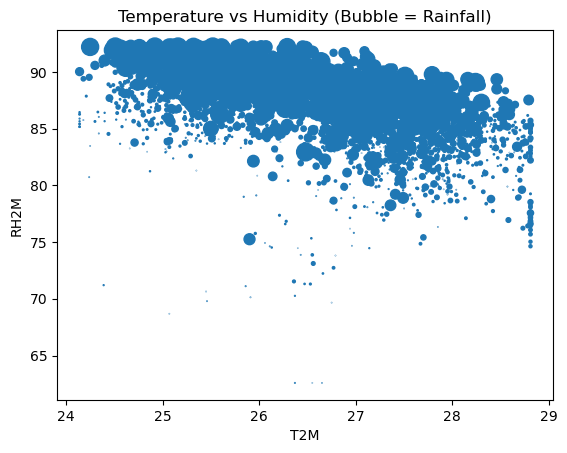

In [24]:
plt.figure()
plt.scatter(
    data["T2M"],
    data["RH2M"],
    s=data["PRECTOTCORR"] * 5  
)

plt.xlabel("T2M")
plt.ylabel("RH2M")
plt.title("Temperature vs Humidity (Bubble = Rainfall)")
plt.show()